In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [15]:
import pandas as pd
G_train = pd.read_csv("GoEmotions/Processed/GoEmotions_train.csv")
G_test = pd.read_csv("GoEmotions/Processed/GoEmotions_test.csv")

G_train = G_train.rename(columns={'0': "text", '1': "label_id", '2': "example_id"})
G_test = G_test.rename(columns={'0': "text", '1': "label_id", '2': "example_id"})

G_emotion_cols = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness", "optimism", "pride",
    "realization", "relief", "remorse", "sadness", "surprise", "neutral"
]

def parse_labels(label_str):
    return [int(x) for x in str(label_str).split(",")]

def make_multilabel_columns(df):
    df = df.copy()

    # Convert "13,18" into [13, 18]
    df["label_list"] = df["label_id"].apply(parse_labels)

    # Add readable labels: [13,18] -> ["excitement", "love"]
    df["label_names"] = df["label_list"].apply(
        lambda ids: [G_emotion_cols[i] for i in ids]
    )

    # Create one binary column per emotion
    for i, emotion in enumerate(G_emotion_cols):
        df[emotion] = df["label_list"].apply(lambda labels: 1 if i in labels else 0)

    return df

G_train = make_multilabel_columns(G_train)
G_test = make_multilabel_columns(G_test)

G_all = pd.concat(
    [G_train, G_test],
    ignore_index=True
)

In [16]:
T_train = pd.read_csv("TwitterEmotions/training.csv")
T_test = pd.read_csv("TwitterEmotions/test.csv")

T_emotion_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

T_emotion_cols = ["sadness", "joy", "love", "anger", "fear", "surprise"]

T_train["emotion"] = T_train["label"].map(T_emotion_map)
T_test["emotion"] = T_test["label"].map(T_emotion_map)

T_all = pd.concat(
    [T_train, T_test],
    ignore_index=True
)

In [17]:
S_train = pd.read_csv("SemEvalDataset/processed/train.csv")
S_test = pd.read_csv("SemEvalDataset/processed/test.csv")

S_emotion_cols = [
    "anger", "anticipation", "disgust", "fear", "joy",
    "love", "optimism", "pessimism", "sadness",
    "surprise", "trust"
]

S_all = pd.concat(
    [S_train, S_test],
    ignore_index=True
)

S_all[S_emotion_cols] = (
    S_all[S_emotion_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

## Dataset Comparison

In [18]:
G_set = set(G_emotion_cols)
T_set = set(T_emotion_cols)
S_set = set(S_emotion_cols)

In [19]:
common_all = G_set & T_set & S_set
G_unique = G_set - (T_set | S_set)
S_unique = S_set - (G_set | T_set)
T_unique = T_set - (G_set | S_set)

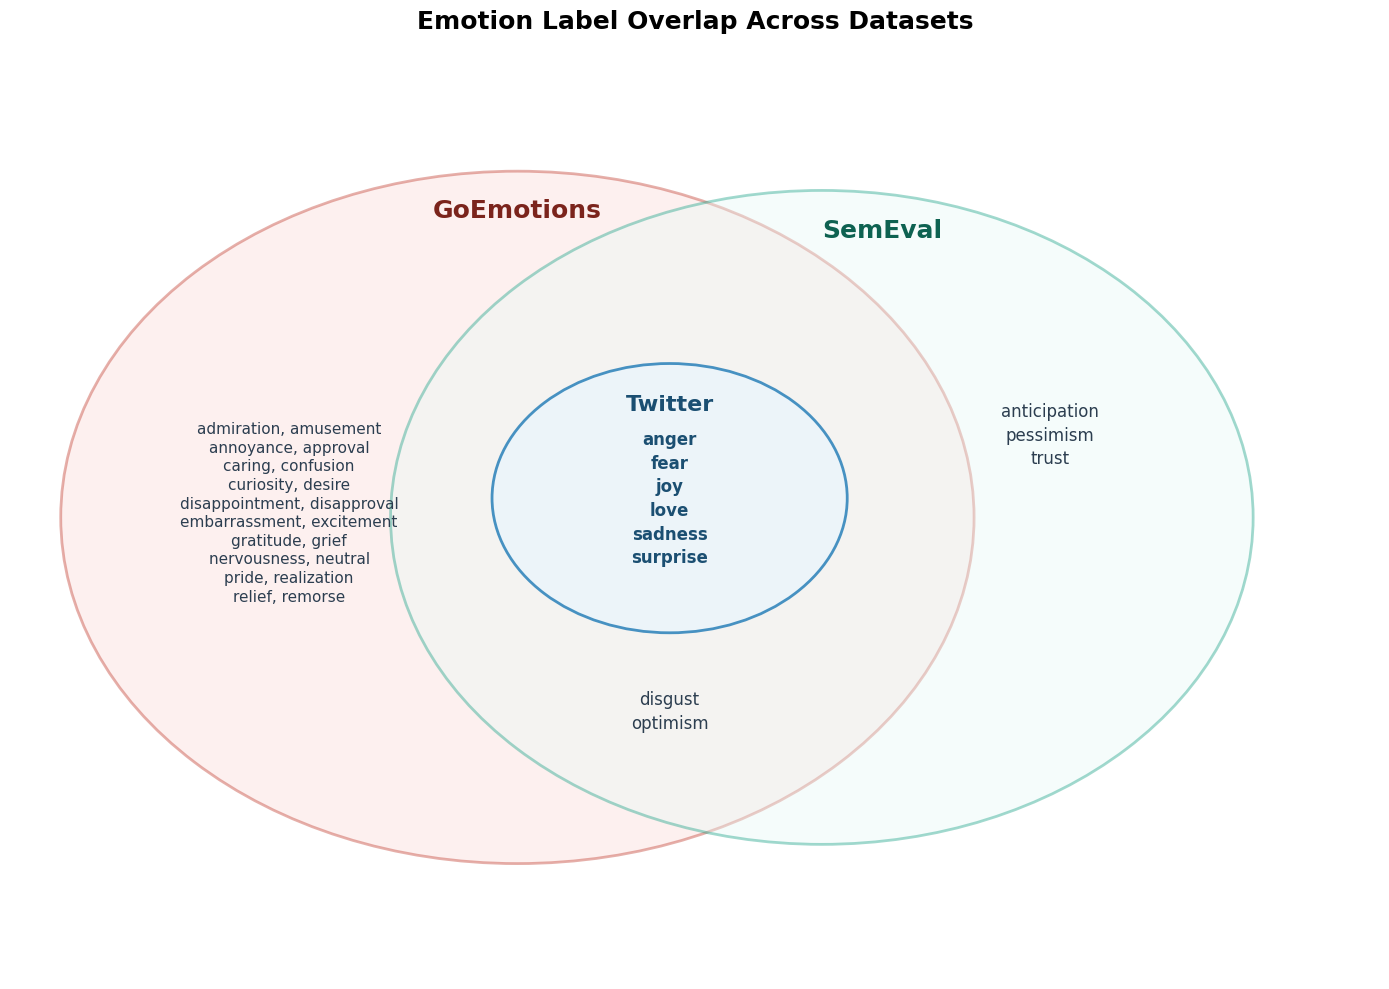

In [20]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches

regions = {
    "100": sorted(G_set - T_set - S_set),          # GoEmotions unique
    "010": sorted(T_set - G_set - S_set),          # Twitter unique (Empty [])
    "001": sorted(S_set - G_set - T_set),          # SemEval unique
    "110": sorted((G_set & T_set) - S_set),        # GoEmotions ∩ Twitter (not SemEval)
    "101": sorted((G_set & S_set) - T_set),        # GoEmotions ∩ SemEval (not Twitter)
    "011": sorted((T_set & S_set) - G_set),        # Twitter ∩ SemEval (not GoEmotions)
    "111": sorted(G_set & T_set & S_set),          # Common to all three
}

# 2. String Formatting Function
def format_region_list(words, max_per_line=2):
    """Formats a list into a clean multi-line string block."""
    if not words:
        return ""
    lines = []
    for i in range(0, len(words), max_per_line):
        lines.append(", ".join(words[i:i + max_per_line]))
    return "\n".join(lines)

# 3. Setup Plot
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(-1.2, 1.5)
ax.set_ylim(-1.2, 1.2)
ax.axis('off')  # Hide background grid axes completely

# 4. Draw Colored Patches & Circles (Clean Hierarchy)
c_goemotions = '#FADBD8'   # Soft Pink
c_semeval = '#E8F8F5'      # Soft Teal
c_twitter = '#EBF5FB'      # Soft Blue

# GoEmotions (Large left circle)
go_circle = patches.Circle((-0.2, 0), radius=0.9, edgecolor='#C0392B', facecolor=c_goemotions, alpha=0.4, linewidth=2)
ax.add_patch(go_circle)

# SemEval (Large right circle)
semeval_circle = patches.Circle((0.4, 0), radius=0.85, edgecolor='#16A085', facecolor=c_semeval, alpha=0.4, linewidth=2)
ax.add_patch(semeval_circle)

# Twitter (Inner nested circle)
twitter_circle = patches.Circle((0.1, 0.05), radius=0.35, edgecolor='#2980B9', facecolor=c_twitter, alpha=0.85, linewidth=2)
ax.add_patch(twitter_circle)

# 5. Place Dataset Titles
# GoEmotions Title
ax.text(-0.2, 0.78, "GoEmotions", fontsize=18, fontweight='bold', ha='center', color='#7B241C')

# SemEval Title (Safely shifted right to clear the intersection line)
ax.text(0.52, 0.73, "SemEval", fontsize=18, fontweight='bold', ha='center', color='#0E6251')

# Twitter Title
ax.text(0.1, 0.28, "Twitter", fontsize=16, fontweight='bold', ha='center', color='#1B4F72')

# 6. Inject Dynamic Data Safely into Layout Regions
# GoEmotions Unique -> regions["100"]
ax.text(-0.65, 0.25, format_region_list(regions["100"], max_per_line=2), 
        fontsize=11, ha='center', va='top', linespacing=1.3, color='#2C3E50')

# SemEval Unique -> regions["001"]
ax.text(0.85, 0.3, format_region_list(regions["001"], max_per_line=1), 
        fontsize=12, ha='center', va='top', linespacing=1.4, color='#2C3E50')

# GoEmotions & SemEval Overlap -> regions["101"]
ax.text(0.1, -0.45, format_region_list(regions["101"], max_per_line=1), 
        fontsize=12, ha='center', va='top', linespacing=1.4, color='#2C3E50')

# All Three Overlap (Twitter Circle) -> regions["111"]
ax.text(0.1, 0.05, format_region_list(regions["111"], max_per_line=1), 
        fontsize=12, ha='center', va='center', fontweight='bold', linespacing=1.4, color='#1B4F72')

# 7. Render Layout
plt.title("Emotion Label Overlap Across Datasets", fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
sentiment_map = {
    "positive": [
        "amusement", "excitement", "joy", "love", "desire", "optimism",
        "caring", "pride", "admiration", "gratitude", "relief", "approval", "trust"
    ],
    "negative": [
        "fear", "nervousness", "remorse", "embarrassment", "disappointment",
        "sadness", "grief", "disgust", "anger", "annoyance", "disapproval", "pessimism"
    ],
    "ambiguous": [
        "realization", "surprise", "curiosity", "confusion", "anticipation"
    ],
    "neutral": [
        "neutral"
    ]
}

In [22]:
# GoEmotions Gender
G_male_mask = G_all["text"].str.contains(
        r"\b(he|him|his)\b",
        case=False,
        regex=True,
        na=False
    )

G_female_mask = G_all["text"].str.contains(
        r"\b(she|her|hers)\b",
        case=False,
        regex=True,
        na=False
    )

G_male_comments = G_all[G_male_mask & ~G_female_mask]
G_female_comments = G_all[G_female_mask & ~G_male_mask]

# Twitter Gender
T_male_mask = T_all["text"].str.contains(
        r"\b(he|him|his)\b",
        case=False,
        regex=True,
        na=False
    )

T_female_mask = T_all["text"].str.contains(
        r"\b(she|her|hers)\b",
        case=False,
        regex=True,
        na=False
    )

T_male_comments = T_all[T_male_mask & ~T_female_mask]
T_female_comments = T_all[T_female_mask & ~T_male_mask]

# SemEval Gender
S_male_mask = S_all["Tweet"].str.contains(
    r"\b(he|him|his)\b",
    case=False,
    regex=True,
    na=False
)

S_female_mask = S_all["Tweet"].str.contains(
    r"\b(she|her|hers)\b",
    case=False,
    regex=True,
    na=False
)

S_male_comments = S_all[S_male_mask & ~S_female_mask]
S_female_comments = S_all[S_female_mask & ~S_male_mask]

/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_64501/3398132750.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  G_male_mask = G_all["text"].str.contains(
/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_64501/3398132750.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  G_female_mask = G_all["text"].str.contains(
/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_64501/3398132750.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  T_male_mask = T_all["text"].str.contains(
/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_64501/3398132750.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  T_

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Universal sentiment map
# --------------------------------------------------

sentiment_map = {
    "positive": [
        "amusement", "excitement", "joy", "love", "desire", "optimism",
        "caring", "pride", "admiration", "gratitude", "relief", "approval",
        "trust"
    ],
    "negative": [
        "fear", "nervousness", "remorse", "embarrassment", "disappointment",
        "sadness", "grief", "disgust", "anger", "annoyance", "disapproval",
        "pessimism"
    ],
    "ambiguous": [
        "realization", "surprise", "curiosity", "confusion", "anticipation"
    ],
    "neutral": [
        "neutral"
    ]
}

sentiment_order = ["positive", "negative", "ambiguous", "neutral"]

# --------------------------------------------------
# Helper function for multi-label datasets
# GoEmotions and SemEval
# --------------------------------------------------

def multilabel_sentiment_by_gender(male_df, female_df, emotion_cols, dataset_name):
    rows = []

    for sentiment, emotions in sentiment_map.items():
        existing_emotions = [
            emotion for emotion in emotions
            if emotion in emotion_cols
        ]

        if len(existing_emotions) == 0:
            male_pct = 0
            female_pct = 0
        else:
            male_pct = (
                (male_df[existing_emotions].sum(axis=1) > 0).mean() * 100
            )

            female_pct = (
                (female_df[existing_emotions].sum(axis=1) > 0).mean() * 100
            )

        rows.append({
            "Dataset": dataset_name,
            "Sentiment": sentiment,
            "Male %": male_pct,
            "Female %": female_pct,
            "Difference": female_pct - male_pct
        })

    return pd.DataFrame(rows)


# --------------------------------------------------
# Helper function for single-label Twitter dataset
# --------------------------------------------------

def singlelabel_sentiment_by_gender(male_df, female_df, dataset_name):
    rows = []

    for sentiment, emotions in sentiment_map.items():
        existing_emotions = [
            emotion for emotion in emotions
            if emotion in T_emotion_cols
        ]

        if len(existing_emotions) == 0:
            male_pct = 0
            female_pct = 0
        else:
            male_pct = (
                male_df["emotion"].isin(existing_emotions).mean() * 100
            )

            female_pct = (
                female_df["emotion"].isin(existing_emotions).mean() * 100
            )

        rows.append({
            "Dataset": dataset_name,
            "Sentiment": sentiment,
            "Male %": male_pct,
            "Female %": female_pct,
            "Difference": female_pct - male_pct
        })

    return pd.DataFrame(rows)


# --------------------------------------------------
# Build sentiment comparison tables
# --------------------------------------------------

G_sentiment_gender = multilabel_sentiment_by_gender(
    G_male_comments,
    G_female_comments,
    G_emotion_cols,
    "GoEmotions"
)

S_sentiment_gender = multilabel_sentiment_by_gender(
    S_male_comments,
    S_female_comments,
    S_emotion_cols,
    "SemEval"
)

T_sentiment_gender = singlelabel_sentiment_by_gender(
    T_male_comments,
    T_female_comments,
    "Twitter"
)

sentiment_gender_comparison = pd.concat(
    [
        G_sentiment_gender,
        S_sentiment_gender,
        T_sentiment_gender
    ],
    ignore_index=True
)

sentiment_gender_comparison["Sentiment"] = pd.Categorical(
    sentiment_gender_comparison["Sentiment"],
    categories=sentiment_order,
    ordered=True
)

sentiment_gender_comparison = sentiment_gender_comparison.sort_values(
    ["Dataset", "Sentiment"]
)

sentiment_gender_comparison

,Dataset,Sentiment,Male %,Female %,Difference
0,GoEmotions,positive,35.251955,36.363636,1.111682
1,GoEmotions,negative,21.372719,23.717372,2.344652
2,GoEmotions,ambiguous,12.597741,12.331233,-0.266508
3,GoEmotions,neutral,39.031277,36.228623,-2.802654
4,SemEval,positive,29.640288,29.396325,-0.243962
5,SemEval,negative,47.338129,45.669291,-1.668838
6,SemEval,ambiguous,11.798561,12.598425,0.799864
7,SemEval,neutral,0.000000,0.000000,0.000000
8,Twitter,positive,41.941565,41.495601,-0.445963
9,Twitter,negative,54.476909,54.838710,0.361801


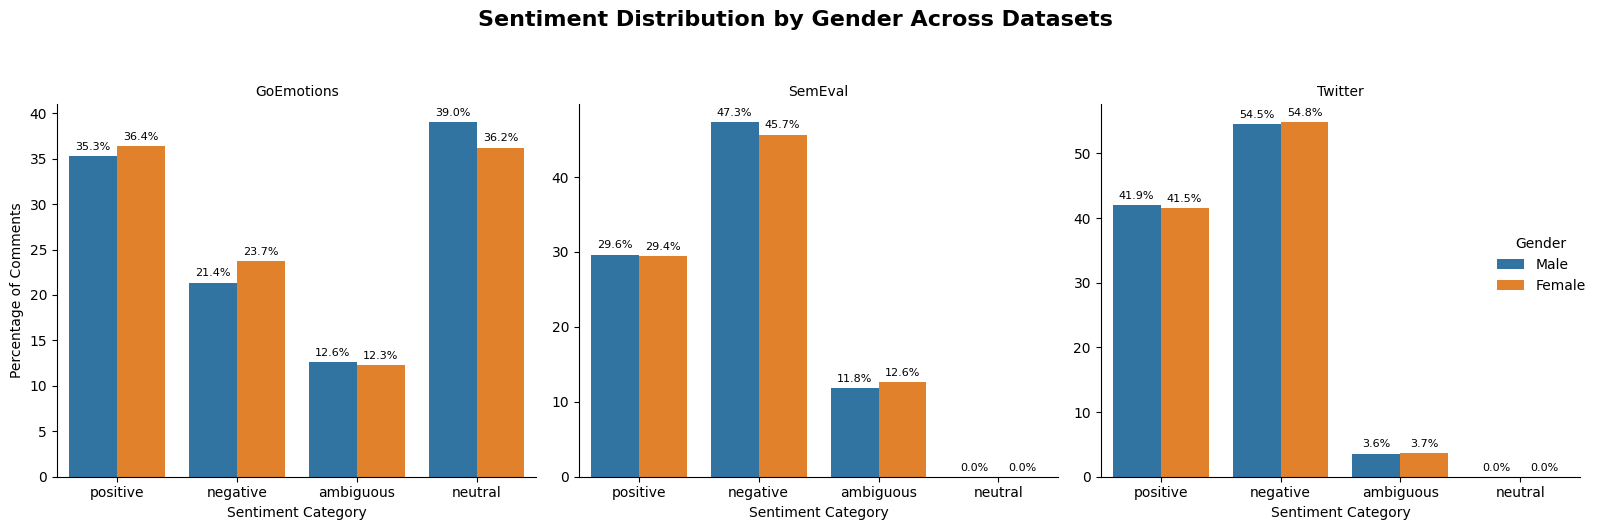

In [24]:
# --------------------------------------------------
# Convert to long format for grouped bar chart
# --------------------------------------------------

plot_df = sentiment_gender_comparison.melt(
    id_vars=["Dataset", "Sentiment"],
    value_vars=["Male %", "Female %"],
    var_name="Gender",
    value_name="Percentage"
)

plot_df["Gender"] = plot_df["Gender"].str.replace(" %", "")

# --------------------------------------------------
# Plot sentiment distribution by gender for each dataset
# --------------------------------------------------

g = sns.catplot(
    data=plot_df,
    x="Sentiment",
    y="Percentage",
    hue="Gender",
    col="Dataset",
    kind="bar",
    height=5,
    aspect=1,
    sharey=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Sentiment Category", "Percentage of Comments")
g.fig.suptitle(
    "Sentiment Distribution by Gender Across Datasets",
    fontsize=16,
    fontweight="bold",
    y=1.05
)

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=0)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [34]:
# Common emotions across all datasets
common_emotions = sorted(list(common_all))

print(common_emotions)

# GoEmotions
G_combined = G_all[
    ["text"] + common_emotions
].copy()

G_combined["Dataset"] = "GoEmotions"

# SemEval
S_combined = S_all.rename(
    columns={"Tweet": "text"}
)

S_combined = S_combined[
    ["text"] + common_emotions
].copy()

S_combined["Dataset"] = "SemEval"

# Twitter
T_combined = T_all[["text", "emotion"]].copy()

for emotion in common_emotions:
    T_combined[emotion] = (
        T_combined["emotion"] == emotion
    ).astype(int)

T_combined = T_combined[
    ["text"] + common_emotions
]

T_combined["Dataset"] = "Twitter"

# Merge all datasets
combined_df = pd.concat(
    [
        G_combined,
        S_combined,
        T_combined
    ],
    ignore_index=True
)

combined_df.head()

['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


,text,anger,fear,joy,love,sadness,surprise,Dataset
0,My favourite food is anything I didn't have to cook myself.,0,0,0,0,0,0,GoEmotions
1,"Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead",0,0,0,0,0,0,GoEmotions
2,WHY THE FUCK IS BAYLESS ISOING,1,0,0,0,0,0,GoEmotions
3,To make her feel threatened,0,1,0,0,0,0,GoEmotions
4,Dirty Southern Wankers,0,0,0,0,0,0,GoEmotions


In [35]:
# Quick sanity checks
print("Combined shape:")
print(combined_df.shape)

print("\nDataset counts:")
print(combined_df["Dataset"].value_counts())

print("\nEmotion frequencies:")
print(
    combined_df[common_emotions]
    .sum()
    .sort_values(ascending=False)
)

Combined shape:
(76934, 8)

Dataset counts:
Dataset
GoEmotions    48837
Twitter       18000
SemEval       10097
Name: count, dtype: int64

Emotion frequencies:
joy         10147
sadness      8737
anger        6743
love         4487
fear         4077
surprise     2200
dtype: int64


# Vocab Differences For Emotions Across Datasets

In [37]:
# Clean text helper

custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "im", "ive", "dont", "didnt", "doesnt", "cant", "couldnt",
    "wouldnt", "isnt", "arent", "wasnt", "werent",
    "feel", "feeling", "felt", "like", "just", "really",
    "know", "time", "people", "day", "going", "want"
})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [
        word for word in words
        if word not in custom_stopwords and len(word) > 2
    ]
    return words

In [38]:
# Top words by dataset and emotion

vocab_rows = []

for dataset in combined_df["Dataset"].unique():
    dataset_df = combined_df[combined_df["Dataset"] == dataset]

    for emotion in common_emotions:
        emotion_texts = dataset_df.loc[
            dataset_df[emotion] == 1,
            "text"
        ]

        all_words = []

        for text in emotion_texts:
            all_words.extend(clean_text(text))

        top_words = [
            word for word, count in Counter(all_words).most_common(10)
        ]

        vocab_rows.append({
            "Dataset": dataset,
            "Emotion": emotion,
            "Sample Count": len(emotion_texts),
            "Top Words": top_words
        })

emotion_vocab_comparison = pd.DataFrame(vocab_rows)

# Cleaner table layout: emotions as rows, datasets as columns

vocab_pivot = emotion_vocab_comparison.pivot(
    index="Emotion",
    columns="Dataset",
    values="Top Words"
)

pd.set_option("display.max_colwidth", None)

vocab_pivot

Dataset,GoEmotions,SemEval,Twitter
Emotion,,,
anger,"[fuck, hate, fucking, don, stupid, shit, hell, damn, stop, angry]","[don, amp, angry, anger, fucking, awful, terrible, got, rage, fuming]","[little, things, angry, think, way, bit, don, cold, irritable, greedy]"
fear,"[scared, terrible, afraid, scary, horrible, terrifying, don, fear, worried, cringe]","[fear, anxiety, nervous, nightmare, don, terrorism, amp, horror, panic, terror]","[little, bit, strange, nervous, anxious, think, terrified, afraid, scared, weird]"
joy,"[happy, glad, enjoy, good, fun, love, makes, got, don, enjoyed]","[happy, love, amp, good, smile, don, watch, amazing, hilarious, lol]","[make, think, good, life, little, pretty, love, happy, things, way]"
love,"[love, loved, favorite, good, don, loves, man, think, game, guy]","[love, happy, smile, amp, good, amazing, birthday, laughter, watch, life]","[love, loving, sweet, passionate, caring, sympathetic, life, liked, little, hot]"
sadness,"[sad, sorry, bad, sadly, don, miss, poor, hard, crying, man]","[sad, don, amp, depression, sadness, lost, today, got, depressing, life]","[little, life, bit, think, things, make, way, don, pretty, love]"
surprise,"[wow, surprised, wonder, omg, didn, believe, shocked, did, wondering, surprise]","[shocking, amp, watch, did, amazing, hilarious, don, lol, live, didn]","[amazed, impressed, overwhelmed, curious, weird, surprised, strange, funny, little, amazing]"


## Observing Positivity Between Platform

In [39]:
# Sentiment distribution by dataset

sentiment_rows = []

for dataset in combined_df["Dataset"].unique():

    dataset_df = combined_df[
        combined_df["Dataset"] == dataset
    ]

    total_labels = 0
    sentiment_counts = {}

    for sentiment, emotions in sentiment_map.items():

        valid_emotions = [
            emotion for emotion in emotions
            if emotion in common_emotions
        ]

        count = dataset_df[valid_emotions].sum().sum()

        sentiment_counts[sentiment] = count
        total_labels += count

    for sentiment, count in sentiment_counts.items():

        sentiment_rows.append({
            "Dataset": dataset,
            "Sentiment": sentiment.capitalize(),
            "Count": count,
            "Percentage": 100 * count / total_labels
        })

sentiment_distribution = pd.DataFrame(sentiment_rows)

sentiment_distribution

,Dataset,Sentiment,Count,Percentage
0,GoEmotions,Positive,3937.0,43.459543
1,GoEmotions,Negative,3921.0,43.282923
2,GoEmotions,Ambiguous,1201.0,13.257534
3,GoEmotions,Neutral,0.0,0.000000
4,SemEval,Positive,3177.0,34.044149
5,SemEval,Negative,5794.0,62.087441
6,SemEval,Ambiguous,361.0,3.868410
7,SemEval,Neutral,0.0,0.000000
8,Twitter,Positive,7520.0,41.777778
9,Twitter,Negative,9842.0,54.677778


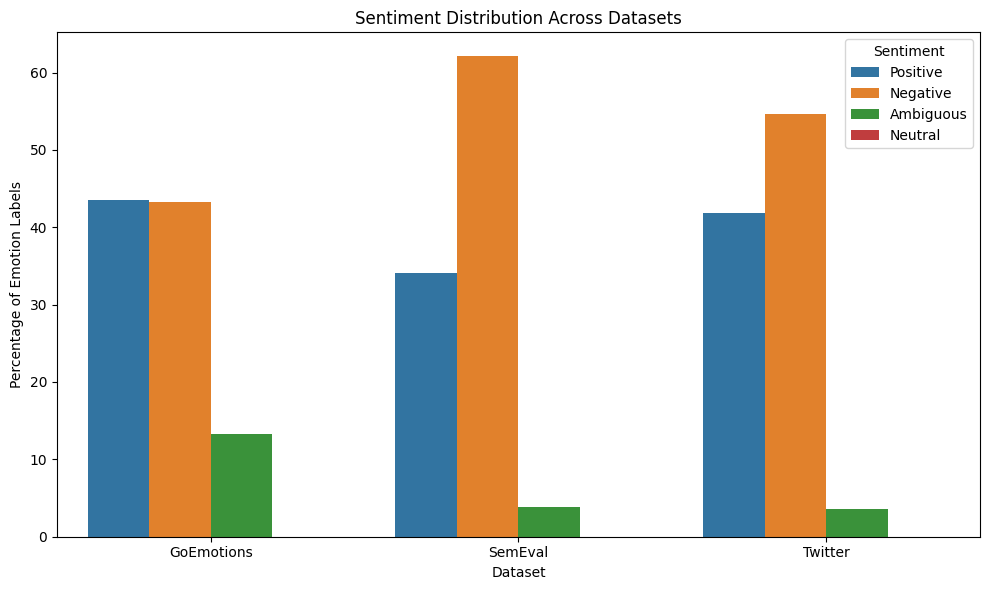

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=sentiment_distribution,
    x="Dataset",
    y="Percentage",
    hue="Sentiment"
)

plt.title("Sentiment Distribution Across Datasets")
plt.ylabel("Percentage of Emotion Labels")
plt.xlabel("Dataset")

plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

## Emotion Distribution Per Dataset

In [41]:
# Emotion percentages by dataset

emotion_distribution = (
    combined_df
    .groupby("Dataset")[common_emotions]
    .sum()
)

emotion_distribution = emotion_distribution.div(
    emotion_distribution.sum(axis=1),
    axis=0
) * 100

emotion_distribution = emotion_distribution.round(2)

emotion_distribution

,anger,fear,joy,love,sadness,surprise
Dataset,,,,,,
GoEmotions,19.48,7.44,17.81,25.65,16.36,13.26
SemEval,27.26,13.31,26.54,7.50,21.52,3.87
Twitter,13.52,12.01,33.65,8.13,29.15,3.54


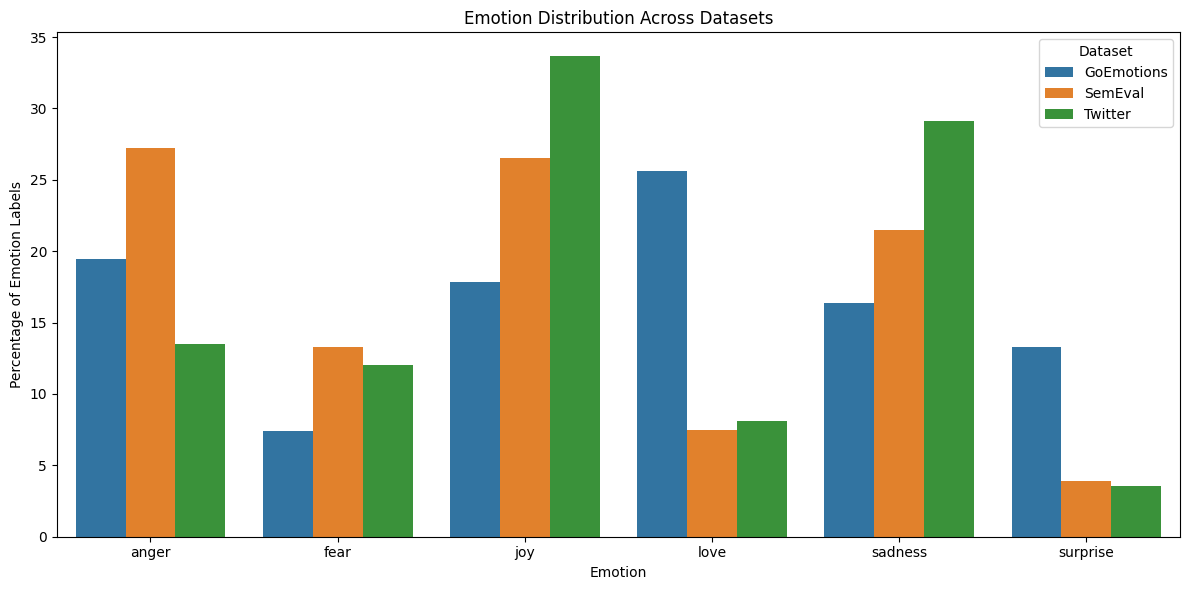

In [42]:
emotion_distribution_long = (
    emotion_distribution
    .reset_index()
    .melt(
        id_vars="Dataset",
        var_name="Emotion",
        value_name="Percentage"
    )
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=emotion_distribution_long,
    x="Emotion",
    y="Percentage",
    hue="Dataset"
)

plt.title("Emotion Distribution Across Datasets")
plt.ylabel("Percentage of Emotion Labels")
plt.xlabel("Emotion")

plt.tight_layout()
plt.show()